In [1]:
# Importing libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load Dataset

# df = pd.read_csv("data/netflix_data.csv")
df = pd.read_csv(r"C:\Users\pashi\Downloads\netflix_india_yt_data.csv")

In [3]:
df.head()

,video_id,title,description,tags,publishedAt,thumbnails,liveBroadcastContent,viewCount,likeCount,commentCount,duration
0,KQ2a4uawQBo,Meet THE REAL Honey Singh | Yo Yo Honey Singh:...,Honey Singh shares his battles with mental hea...,"['angreji beat', 'dope shope', 'honey singh', ...",2024-12-20T08:00:00Z,{'default': {'url': 'https://i.ytimg.com/vi/KQ...,none,52864,7111.0,394.0,PT1M11S
1,bOR7S0j_wq8,⁠Akshay Kumar ALMOST Gets Caught Cheating! 👀 f...,Brb taking notes on how to lie like a pro 👀\r\...,"['aditya seal', 'akshay kumar', 'akshay kumar ...",2024-12-19T12:30:00Z,{'default': {'url': 'https://i.ytimg.com/vi/bO...,none,44300,642.0,30.0,PT3M2S
2,GRM8Q-1fVJ0,Black Warrant | Official Teaser | Vikramaditya...,"India ki sabse khatarnaak jail mein, ek naya j...","['netflix india', 'netflix', 'netflix shows', ...",2024-12-19T05:30:10Z,{'default': {'url': 'https://i.ytimg.com/vi/GR...,none,201087,3300.0,101.0,PT1M15S
3,b0b8WBglCHo,The Electric State | Official Trailer | Netfli...,"In the aftermath of the robot war, the only pa...","['AGBO', 'Action', 'Adventure', 'Anthony Russo...",2024-12-18T14:30:00Z,{'default': {'url': 'https://i.ytimg.com/vi/b0...,none,19642,354.0,25.0,PT1M44S
4,QCPOl_7cdnQ,The Electric State | Official Trailer | Hindi ...,"In the aftermath of the robot war, the only pa...","['AGBO', 'Netflix', 'Netflix पर क्या देखना चाह...",2024-12-18T13:30:05Z,{'default': {'url': 'https://i.ytimg.com/vi/QC...,none,117292,3455.0,130.0,PT1M41S


- video_id: 
This field represents the specific YouTube video's unique identification code, which is assigned to each video on the platform.


- title: The title of the YouTube video is the text that appears as the main heading when the video is viewed on the platform.


- description: 
The description is a text field where content creators can provide a more detailed explanation of the video's content. It allows creators to provide additional context, links, and information to help viewers understand what the video is about.


- tags: 
Tags are keywords or phrases that content creators use to describe the content of their YouTube videos. These tags help users discover videos 
related to specific topics or themes.


- publishedAt: 
This timestamp indicates the date and time when the YouTube video was originally published on the platform. 


- thumbnails: 
Thumbnails are images or visual representations that users see when browsing YouTube. They serve as previews of the video content and can be provided in JSON format, typically containing different quality versions of the thumbnail image.


- viewCount: 
The view count signifies how many times this specific video has been watched by YouTube users up to the date when the data was gathered. It provides an indication of the video's popularity and reach.
		

- likeCount: 
Like count refers to the number of times viewers have clicked the "like" button on the video, indicating their appreciation or approval of its content.


- commentCount: 
Comment count represents the number of comments that users have posted on this video. Comments allow viewers to engage with the video's content and share their thoughts or feedback.


- duration: 
The duration of the video is provided in ISO 8601 standard format. This format specifies the length of the video in hours, minutes, and seconds, making it easy to understand the video's length at a glance.

Example: PT26M12S (26 Minutes 12 seconds), PT1H26M10S (1 Hour 26 Minutes 10 Seconds)




# Explore Datasets

In [4]:
# Print the number of rows and columns in dataset
df.shape

(5198, 11)

In [5]:
df.describe()

,viewCount,likeCount,commentCount
count,5.198000e+03,5.197000e+03,5191.000000
mean,2.154679e+06,2.635686e+04,654.778463
std,1.794774e+07,9.341496e+04,2021.089963
min,0.000000e+00,1.200000e+01,0.000000
25%,5.890825e+04,1.245000e+03,43.000000
50%,2.210810e+05,4.499000e+03,144.000000
75%,9.379675e+05,1.930900e+04,507.500000
max,8.883307e+08,3.192608e+06,59038.000000


# Data Cleaning 

In [6]:
# Check missing values in each column

df.isnull().sum()

video_id                 0
title                    0
description              7
tags                    21
publishedAt              0
thumbnails               0
liveBroadcastContent     0
viewCount                0
likeCount                1
commentCount             7
duration                 0
dtype: int64

In [7]:
# Fill missing values in 'tags' column with empty string
# Reason: Tags are used for counting keywords, so empty is better than NaN
df['tags'] = df['tags'].fillna('')

# Fill missing values in 'likeCount' with 0
# Reason: Missing likes means no engagement recorded
df['likeCount'] = df['likeCount'].fillna(0)

# Fill missing values in 'commentCount' with 0
# Reason: Missing comments treated as no comments
df['commentCount'] = df['commentCount'].fillna(0)

In [8]:
# Check for Duplicates

df.duplicated().sum()

0

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5198 entries, 0 to 5197
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   video_id              5198 non-null   object 
 1   title                 5198 non-null   object 
 2   description           5191 non-null   object 
 3   tags                  5198 non-null   object 
 4   publishedAt           5198 non-null   object 
 5   thumbnails            5198 non-null   object 
 6   liveBroadcastContent  5198 non-null   object 
 7   viewCount             5198 non-null   int64  
 8   likeCount             5198 non-null   float64
 9   commentCount          5198 non-null   float64
 10  duration              5198 non-null   object 
dtypes: float64(2), int64(1), object(8)
memory usage: 446.8+ KB


In [10]:
# Convert publishedAt to datetime (UTC)
df['publishedAt'] = pd.to_datetime(df['publishedAt'], utc=True)

# Convert UTC to IST (Asia/Kolkata timezone)
df['publishedAt_IST'] = df['publishedAt'].dt.tz_convert('Asia/Kolkata')

# Extract Date (normalized, no time)
df['Date'] = df['publishedAt_IST'].dt.normalize()

# Extract Time
df['Time'] = df['publishedAt_IST'].dt.time

# Extract Day Name (e.g., Monday, Tuesday)
df['publish_day'] = df['publishedAt_IST'].dt.day_name()

# Extract Hour (very useful for analysis)
df['Hour'] = df['publishedAt_IST'].dt.hour

In [11]:
# Convert to integer after handling missing values

df['likeCount'] = df['likeCount'].fillna(0).astype(int)
df['commentCount'] = df['commentCount'].fillna(0).astype(int)

In [12]:
df.head()

,video_id,title,description,tags,publishedAt,thumbnails,liveBroadcastContent,viewCount,likeCount,commentCount,duration,publishedAt_IST,Date,Time,publish_day,Hour
0,KQ2a4uawQBo,Meet THE REAL Honey Singh | Yo Yo Honey Singh:...,Honey Singh shares his battles with mental hea...,"['angreji beat', 'dope shope', 'honey singh', ...",2024-12-20 08:00:00+00:00,{'default': {'url': 'https://i.ytimg.com/vi/KQ...,none,52864,7111,394,PT1M11S,2024-12-20 13:30:00+05:30,2024-12-20 00:00:00+05:30,13:30:00,Friday,13
1,bOR7S0j_wq8,⁠Akshay Kumar ALMOST Gets Caught Cheating! 👀 f...,Brb taking notes on how to lie like a pro 👀\r\...,"['aditya seal', 'akshay kumar', 'akshay kumar ...",2024-12-19 12:30:00+00:00,{'default': {'url': 'https://i.ytimg.com/vi/bO...,none,44300,642,30,PT3M2S,2024-12-19 18:00:00+05:30,2024-12-19 00:00:00+05:30,18:00:00,Thursday,18
2,GRM8Q-1fVJ0,Black Warrant | Official Teaser | Vikramaditya...,"India ki sabse khatarnaak jail mein, ek naya j...","['netflix india', 'netflix', 'netflix shows', ...",2024-12-19 05:30:10+00:00,{'default': {'url': 'https://i.ytimg.com/vi/GR...,none,201087,3300,101,PT1M15S,2024-12-19 11:00:10+05:30,2024-12-19 00:00:00+05:30,11:00:10,Thursday,11
3,b0b8WBglCHo,The Electric State | Official Trailer | Netfli...,"In the aftermath of the robot war, the only pa...","['AGBO', 'Action', 'Adventure', 'Anthony Russo...",2024-12-18 14:30:00+00:00,{'default': {'url': 'https://i.ytimg.com/vi/b0...,none,19642,354,25,PT1M44S,2024-12-18 20:00:00+05:30,2024-12-18 00:00:00+05:30,20:00:00,Wednesday,20
4,QCPOl_7cdnQ,The Electric State | Official Trailer | Hindi ...,"In the aftermath of the robot war, the only pa...","['AGBO', 'Netflix', 'Netflix पर क्या देखना चाह...",2024-12-18 13:30:05+00:00,{'default': {'url': 'https://i.ytimg.com/vi/QC...,none,117292,3455,130,PT1M41S,2024-12-18 19:00:05+05:30,2024-12-18 00:00:00+05:30,19:00:05,Wednesday,19


# FEATURE ENGINEERING

In [13]:
# Count number of tags per video (split by ',')

df['TagsCount'] = df['tags'].apply(lambda x: len(str(x).split(',')))

In [14]:
# Convert ISO duration (PT format) into total seconds

# Import regular expression module for parsing ISO 8601 duration format
import re

# Function to convert ISO 8601 duration (e.g., PT1H2M30S) into total seconds
def convert_iso_to_seconds(duration):
    
    # Handle missing values by returning 0 seconds
    if pd.isna(duration):
        return 0

    # Define regex pattern to extract hours, minutes, and seconds
    pattern = re.compile(r'PT(?:(\d+)H)?(?:(\d+)M)?(?:(\d+)S)?')
    
    # Match the pattern with duration string
    match = pattern.match(str(duration))

    # If pattern does not match, return 0 (invalid format)
    if not match:
        return 0

    # Extract hours, minutes, and seconds safely
    hours = int(match.group(1)) if match.group(1) else 0
    minutes = int(match.group(2)) if match.group(2) else 0
    seconds = int(match.group(3)) if match.group(3) else 0

    # Convert total duration into seconds
    return hours * 3600 + minutes * 60 + seconds


# Apply the function to create a new column 'duration_sec'
df['duration_sec'] = df['duration'].apply(convert_iso_to_seconds)

In [15]:
# Classify videos as Short (≤60s) or Long (>60s)

df['Category'] = df['duration_sec'].apply(
    lambda x: 'Short' if x <= 60 else 'Long'
)

In [16]:
# Count the number of videos in each category (Short vs Long)

df['Category'].value_counts()

Category
Long     4342
Short     856
Name: count, dtype: int64

In [17]:
# Calculate engagement rate to measure user interaction with videos

df['engagement_rate'] = df.apply(
    lambda x: (x['likeCount'] + x['commentCount']) / x['viewCount'] 
    if x['viewCount'] != 0 else 0,
    axis=1
)

In [18]:
df.head()

,video_id,title,description,tags,publishedAt,thumbnails,liveBroadcastContent,viewCount,likeCount,commentCount,duration,publishedAt_IST,Date,Time,publish_day,Hour,TagsCount,duration_sec,Category,engagement_rate
0,KQ2a4uawQBo,Meet THE REAL Honey Singh | Yo Yo Honey Singh:...,Honey Singh shares his battles with mental hea...,"['angreji beat', 'dope shope', 'honey singh', ...",2024-12-20 08:00:00+00:00,{'default': {'url': 'https://i.ytimg.com/vi/KQ...,none,52864,7111,394,PT1M11S,2024-12-20 13:30:00+05:30,2024-12-20 00:00:00+05:30,13:30:00,Friday,13,19,71,Long,0.141968
1,bOR7S0j_wq8,⁠Akshay Kumar ALMOST Gets Caught Cheating! 👀 f...,Brb taking notes on how to lie like a pro 👀\r\...,"['aditya seal', 'akshay kumar', 'akshay kumar ...",2024-12-19 12:30:00+00:00,{'default': {'url': 'https://i.ytimg.com/vi/bO...,none,44300,642,30,PT3M2S,2024-12-19 18:00:00+05:30,2024-12-19 00:00:00+05:30,18:00:00,Thursday,18,23,182,Long,0.015169
2,GRM8Q-1fVJ0,Black Warrant | Official Teaser | Vikramaditya...,"India ki sabse khatarnaak jail mein, ek naya j...","['netflix india', 'netflix', 'netflix shows', ...",2024-12-19 05:30:10+00:00,{'default': {'url': 'https://i.ytimg.com/vi/GR...,none,201087,3300,101,PT1M15S,2024-12-19 11:00:10+05:30,2024-12-19 00:00:00+05:30,11:00:10,Thursday,11,30,75,Long,0.016913
3,b0b8WBglCHo,The Electric State | Official Trailer | Netfli...,"In the aftermath of the robot war, the only pa...","['AGBO', 'Action', 'Adventure', 'Anthony Russo...",2024-12-18 14:30:00+00:00,{'default': {'url': 'https://i.ytimg.com/vi/b0...,none,19642,354,25,PT1M44S,2024-12-18 20:00:00+05:30,2024-12-18 00:00:00+05:30,20:00:00,Wednesday,20,20,104,Long,0.019295
4,QCPOl_7cdnQ,The Electric State | Official Trailer | Hindi ...,"In the aftermath of the robot war, the only pa...","['AGBO', 'Netflix', 'Netflix पर क्या देखना चाह...",2024-12-18 13:30:05+00:00,{'default': {'url': 'https://i.ytimg.com/vi/QC...,none,117292,3455,130,PT1M41S,2024-12-18 19:00:05+05:30,2024-12-18 00:00:00+05:30,19:00:05,Wednesday,19,20,101,Long,0.030565


# ANALYSIS

In [19]:
# 1. Does the duration of the video influence the views and comments?

duration_analysis= df.groupby('Category')[['viewCount','commentCount']].mean()

print("Average Views and Comments by Video Duration:\n")
print(duration_analysis)

Average Views and Comments by Video Duration:

             viewCount  commentCount
Category                            
Long      2.364991e+06    736.348457
Short     1.087890e+06    235.665888


• Insight: Long videos generate more than 2x higher average views and significantly more comments compared to short videos, indicating stronger audience reach and deeper engagement.

In [20]:
# 2. Is there a relation between the views and comments?

correlation = df[['viewCount', 'commentCount']].corr()

print("Correlation between Views and Comments:\n")
print(correlation)

Correlation between Views and Comments:

              viewCount  commentCount
viewCount      1.000000      0.142835
commentCount   0.142835      1.000000


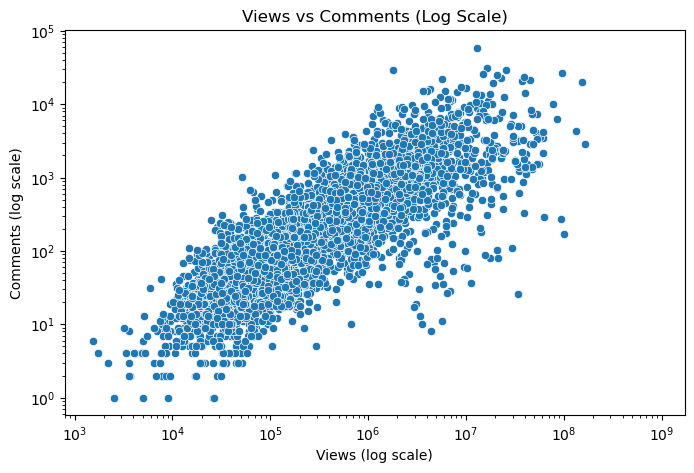

In [21]:
plt.figure(figsize=(8,5))

sns.scatterplot(x='viewCount', y='commentCount', data=df)

plt.xscale('log')
plt.yscale('log')

plt.title("Views vs Comments (Log Scale)")
plt.xlabel("Views (log scale)")
plt.ylabel("Comments (log scale)")

plt.show()

• Insight: A strong positive relationship exists between views and comments, as clearly visible in the log-scaled distribution, indicating that higher-view videos consistently generate higher audience interaction.

In [22]:
# 3. Does tag count matter to get more views?

# Correlation between TagsCount and Views
tag_view_corr = df[['TagsCount', 'viewCount']].corr()

print("Correlation between Tags Count and Views:\n")
print(tag_view_corr)

# Compare average views by tag count buckets (optional but stronger)
df['tag_bucket'] = pd.cut(
    df['TagsCount'],
    bins=[0, 5, 10, 20, 50],
    labels=['0-5', '6-10', '11-20', '21+']
)

tag_bucket_analysis = df.groupby('tag_bucket')['viewCount'].mean()

print("\nAverage Views by Tag Count Bucket:\n")
print(tag_bucket_analysis)

Correlation between Tags Count and Views:

           TagsCount  viewCount
TagsCount   1.000000   0.007347
viewCount   0.007347   1.000000

Average Views by Tag Count Bucket:

tag_bucket
0-5      2.667296e+06
6-10     1.622579e+06
11-20    1.709810e+06
21+      2.506427e+06
Name: viewCount, dtype: float64


C:\Users\pashi\AppData\Local\Temp\ipykernel_16000\3263847340.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tag_bucket_analysis = df.groupby('tag_bucket')['viewCount'].mean()


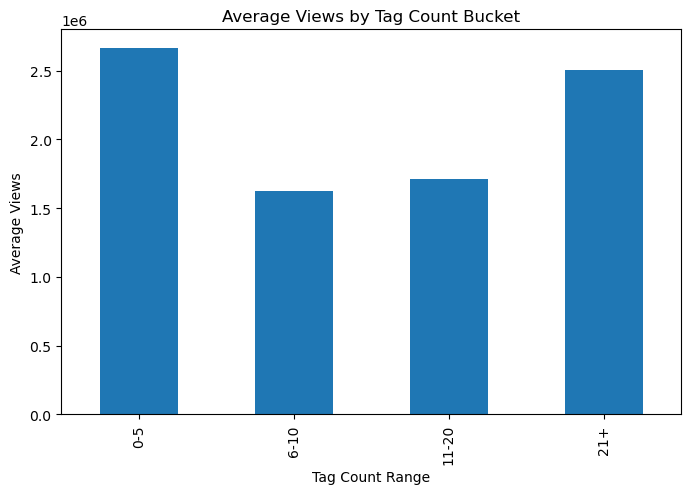

In [23]:
plt.figure(figsize=(8,5))

tag_bucket_analysis.plot(kind='bar')

plt.title("Average Views by Tag Count Bucket")
plt.xlabel("Tag Count Range")
plt.ylabel("Average Views")

plt.show()

• Insight: Tag count does not show a linear impact on views; however, videos with very low (0–5) or very high (21+) tag counts achieve significantly higher average views, while mid-range tag counts (6–20) underperform.

In [24]:
# 4. Does video publishing day or time influence the engagement?

# Using engagement_rate 

# 1. Engagement by Day
engagement_by_day = df.groupby('publish_day')['engagement_rate'].mean().sort_values(ascending=False)

print("Average Engagement Rate by Day:\n")
print(engagement_by_day)


# 2. Engagement by Hour
engagement_by_hour = df.groupby('Hour')['engagement_rate'].mean().sort_values(ascending=False)

print("\nAverage Engagement Rate by Hour:\n")
print(engagement_by_hour)

Average Engagement Rate by Day:

publish_day
Friday       0.026684
Thursday     0.026350
Tuesday      0.026020
Saturday     0.025458
Wednesday    0.024895
Sunday       0.024625
Monday       0.024554
Name: engagement_rate, dtype: float64

Average Engagement Rate by Hour:

Hour
17    0.030305
0     0.029763
13    0.026823
18    0.026741
21    0.026557
22    0.026258
11    0.026100
19    0.025987
16    0.025611
20    0.025152
6     0.024888
8     0.024690
23    0.024399
15    0.024011
10    0.023805
3     0.023426
5     0.023342
14    0.023205
12    0.023098
9     0.022301
7     0.021691
2     0.019989
4     0.018279
1     0.010499
Name: engagement_rate, dtype: float64


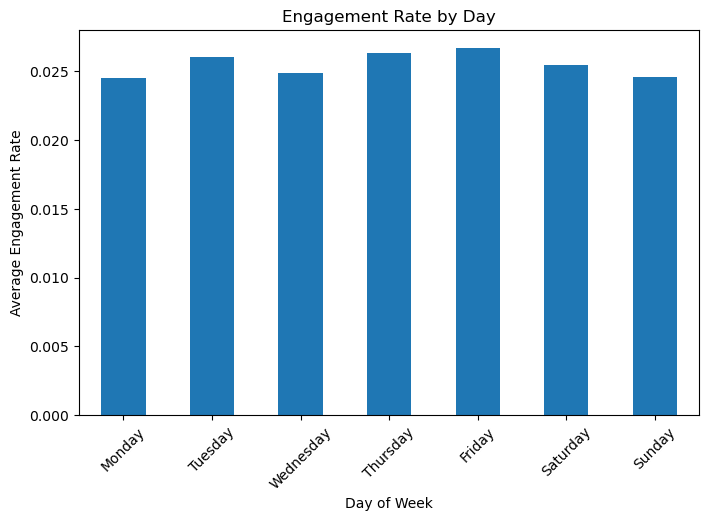

In [25]:
# Order days properly (important 🔥)
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

# Reorder data
engagement_by_day = engagement_by_day.reindex(day_order)

plt.figure(figsize=(8,5))

engagement_by_day.plot(kind='bar')

plt.title("Engagement Rate by Day")
plt.xlabel("Day of Week")
plt.ylabel("Average Engagement Rate")

plt.xticks(rotation=45)

plt.show()

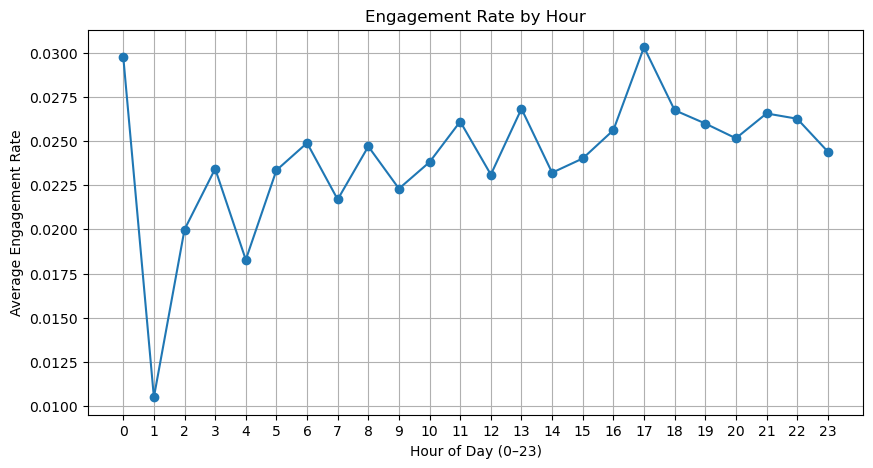

In [26]:
plt.figure(figsize=(10,5))

# Sort hours properly (0–23)
engagement_by_hour = df.groupby('Hour')['engagement_rate'].mean().sort_index()

engagement_by_hour.plot(kind='line', marker='o')

plt.title("Engagement Rate by Hour")
plt.xlabel("Hour of Day (0–23)")
plt.ylabel("Average Engagement Rate")

plt.xticks(range(0,24))
plt.grid(True)

plt.show()

• Insight: Engagement shows minimal variation across days, but varies significantly by time, with a clear peak around 5 PM, indicating that publishing time plays a more critical role in driving audience interaction.

In [27]:
# 5. Which video is most popular on our channel and break down the reasons why it worked well.

# Get the most popular video (highest views)
top_video = df.sort_values(by='viewCount', ascending=False).head(1)

print("Most Popular Video:\n")
print(top_video[['title', 'viewCount', 'likeCount', 'commentCount', 'TagsCount', 'duration_sec']].T)

Most Popular Video:

                                                           4916
title         Mighty Little Bheem | Bheem with a Beat | Netf...
viewCount                                             888330690
likeCount                                               3192608
commentCount                                                  0
TagsCount                                                    28
duration_sec                                                196


In [28]:
# Compare with overall averages
avg_metrics = df[['viewCount', 'likeCount', 'commentCount', 'TagsCount', 'duration_sec']].mean()

print("\nAverage Metrics:\n")
print(avg_metrics)


Average Metrics:

viewCount       2.154679e+06
likeCount       2.635179e+04
commentCount    6.538967e+02
TagsCount       1.849788e+01
duration_sec    2.715329e+02
dtype: float64


• Key Drivers of Success:

1. Massive Reach & Engagement:
   - Views (~88M) are ~40x higher than average
   - Likes (~3.1M) indicate strong audience interest

2. Shorter Duration Advantage:
   - ~196 sec vs ~271 sec average
   - Easier to consume → higher completion rate

3. Strong Tag Strategy:
   - 28 tags (above average)
   - Improves search visibility & recommendations

4. Content Appeal:
   - Popular character (Mighty Little Bheem)
   - Likely broad audience (kids + family)

5. Platform/Brand Power:
   - Netflix branding increases trust & reach

6. Passive Engagement Pattern:
   - 0 comments suggests:
     → Kids content / passive viewing
     → High views without active interaction

In [29]:
# 6. Does title length influence views?

# Created title length feature
df['title_length'] = df['title'].apply(len)

# 1. Correlation Analysis
title_corr = df[['title_length', 'viewCount']].corr()

print("Correlation between Title Length and Views:\n")
print(title_corr)

# 2. Group Analysis (Better Insight)
# Created title length categories
df['title_length_category'] = pd.cut(
    df['title_length'],
    bins=[0, 30, 60, 100],
    labels=['Short', 'Medium', 'Long']
)

title_group_analysis = df.groupby('title_length_category')['viewCount'].mean()

print("\nAverage Views by Title Length Category:\n")
print(title_group_analysis)

Correlation between Title Length and Views:

              title_length  viewCount
title_length      1.000000   0.003943
viewCount         0.003943   1.000000

Average Views by Title Length Category:

title_length_category
Short     2.068422e+06
Medium    2.467908e+06
Long      2.063558e+06
Name: viewCount, dtype: float64


C:\Users\pashi\AppData\Local\Temp\ipykernel_16000\1202239387.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  title_group_analysis = df.groupby('title_length_category')['viewCount'].mean()


• Insight: While title length does not exhibit a strong direct correlation with views, videos with medium-length titles consistently achieve higher average views, indicating that concise yet descriptive titles are more effective in maximizing audience reach.

In [30]:
# 7. What is our views distribution

# Statistical Summary
print("Views Distribution Summary:\n")
print(df['viewCount'].describe())

Views Distribution Summary:

count    5.198000e+03
mean     2.154679e+06
std      1.794774e+07
min      0.000000e+00
25%      5.890825e+04
50%      2.210810e+05
75%      9.379675e+05
max      8.883307e+08
Name: viewCount, dtype: float64


• Insight: The significant difference between mean and median views, along with a very high maximum value, confirms a strong long-tail distribution where a few viral videos disproportionately contribute to total views, while most videos perform within a modest range.

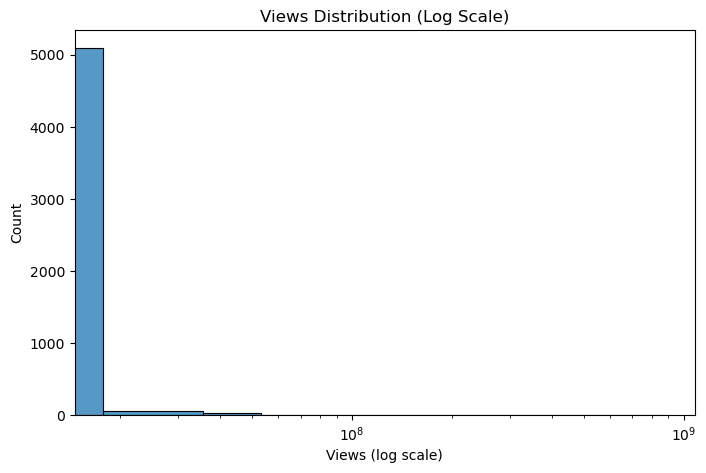

In [31]:
plt.figure(figsize=(8,5))

sns.histplot(df['viewCount'], bins=50)

plt.xscale('log')

plt.title("Views Distribution (Log Scale)")
plt.xlabel("Views (log scale)")
plt.ylabel("Count")

plt.show()

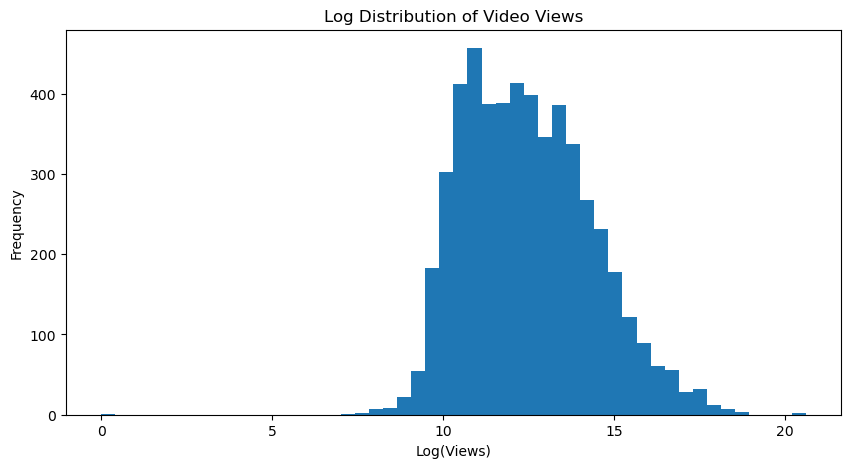

In [32]:
plt.figure(figsize=(10,5))

plt.hist(np.log1p(df['viewCount']), bins=50)

plt.title("Log Distribution of Video Views")
plt.xlabel("Log(Views)")
plt.ylabel("Frequency")

plt.show()

• Insight: Views exhibit a highly skewed distribution in raw form; however, after log transformation, the data approximates a normal distribution, indicating that most videos perform within a similar range, while a small number of outliers drive disproportionately high view counts.

In [33]:
# 8. Are there certain topics or themes that consistently perform better than others?

from collections import Counter
import re

# Combine all titles
all_titles = " ".join(df['title'].dropna()).lower()

# Remove special characters
clean_text = re.sub(r'[^a-zA-Z0-9\s]', '', all_titles)

# Remove common stopwords
stopwords = ['the','and','of','to','a','in','is','for','on','with','at','by','an']

words = [word for word in clean_text.split() if word not in stopwords]

# Count keywords
top_keywords = Counter(words).most_common(15)

print("Top Meaningful Keywords:\n")
print(top_keywords)

Top Meaningful Keywords:

[('netflix', 3907), ('india', 3299), ('trailer', 768), ('official', 751), ('ft', 587), ('2', 362), ('season', 317), ('kapoor', 295), ('more', 260), ('khan', 211), ('scene', 194), ('teaser', 191), ('indian', 185), ('now', 168), ('vijay', 156)]


In [34]:
# High Performing Videos 

top_videos = df.sort_values(by='viewCount', ascending=False).head(100)

top_titles = " ".join(top_videos['title'].dropna()).lower()
clean_text = re.sub(r'[^a-zA-Z0-9\s]', '', top_titles)

words = [word for word in clean_text.split() if word not in stopwords]

top_keywords_perf = Counter(words).most_common(15)

print("\nTop Keywords in High-Performing Videos:\n")
print(top_keywords_perf)


Top Keywords in High-Performing Videos:

[('netflix', 89), ('india', 75), ('official', 57), ('trailer', 55), ('bheem', 16), ('mighty', 10), ('little', 10), ('2', 10), ('season', 8), ('khan', 8), ('vijay', 7), ('kapoor', 6), ('varma', 5), ('hindi', 5), ('scene', 5)]


• Insight: While generic keywords such as "official", "trailer", and "netflix" are common across all videos, high-performing content is distinguished by specific character- and theme-based keywords (e.g., "bheem", "mighty") along with strong Bollywood/Indian context (e.g., "india", "hindi", actor names like "vijay', "kapoor", "khan"), indicating that audience engagement is driven by recognizable content, local relevance, and cultural familiarity.

In [35]:
# 9. Are there any videos that have no tags, but performed well?

df['TagsCount'] = df['tags'].apply(
    lambda x: 0 if pd.isna(x) or x == '' else len(str(x).split('|'))
)

# Identify videos with no tags
no_tag_videos = df[df['TagsCount'] == 0]

print("Total Videos with No Tags:", no_tag_videos.shape[0])

# Filter high-performing videos (>1M views)
high_perf_no_tags = no_tag_videos[no_tag_videos['viewCount'] > 1_000_000]

print("Videos with No Tags but High Performance:")
print(high_perf_no_tags[['title', 'viewCount', 'likeCount', 'commentCount']])

# Count such videos
print("Number of such videos:", high_perf_no_tags.shape[0])

Total Videos with No Tags: 21
Videos with No Tags but High Performance:
                                          title  viewCount  likeCount  \
5056  Ghoul: The Room | Official [VR] | Netflix   18407319      41185   
5077      Ghoul - Silent Trailer I Netflix I HD   18523444      40118   
5112                       Heating Up | Netflix   24051981      26609   
5113                         Ad Break | Netflix    3582965        146   
5114                           To-Dos | Netflix    4419563         36   
5140            Dangal | Main Trailer | Netflix    1253173       5052   

      commentCount  
5056          1823  
5077          2379  
5112          2410  
5113            10  
5114             8  
5140           128  
Number of such videos: 6


In [36]:
# Show top-performing video without tags

high_perf_no_tags.sort_values(by='viewCount', ascending=False).head(1)

,video_id,title,description,tags,publishedAt,thumbnails,liveBroadcastContent,viewCount,likeCount,commentCount,...,Time,publish_day,Hour,TagsCount,duration_sec,Category,engagement_rate,tag_bucket,title_length,title_length_category
5112,asxx8fnzjBQ,Heating Up | Netflix,"All the hottest stories. Anytime, anywhere. Wa...",,2018-04-02 07:10:31+00:00,{'default': {'url': 'https://i.ytimg.com/vi/as...,none,24051981,26609,2410,...,12:40:31,Monday,12,0,31,Short,0.001207,0-5,20,Short


Insight:
- There are videos with no tags that still achieved high views.
- Out of 21 no-tag videos, 6 videos crossed 1M views.

This indicates that tags are not the only factor driving performance.

Key reasons for success:
1. Strong brand value (Netflix)
2. Popular or trending content
3. Engaging titles (e.g., trailers, known shows)
4. High audience interest

In [37]:
# 10.What is the frequency of video publishing?

# Videos per Day
videos_per_day = df.groupby('Date')['video_id'].count()

print("Publishing Frequency (Videos per Day):\n")
print(videos_per_day.head())

# Average Videos per Day
avg_videos_per_day = videos_per_day.mean()

print("\nAverage Videos Published Per Day:", round(avg_videos_per_day, 2))

# Videos per Month (Better Insight)
df['Month'] = df['Date'].dt.to_period('M')

videos_per_month = df.groupby('Month')['video_id'].count()

print("\nPublishing Frequency (Videos per Month):\n")
print(videos_per_month)

Publishing Frequency (Videos per Day):

Date
2016-05-17 00:00:00+05:30    1
2016-06-13 00:00:00+05:30    1
2016-06-15 00:00:00+05:30    1
2016-06-17 00:00:00+05:30    1
2016-07-08 00:00:00+05:30    1
Name: video_id, dtype: int64

Average Videos Published Per Day: 2.36

Publishing Frequency (Videos per Month):

Month
2016-05      1
2016-06      3
2016-07      4
2016-08      5
2016-09      7
          ... 
2024-08    107
2024-09     94
2024-10    103
2024-11     94
2024-12     56
Freq: M, Name: video_id, Length: 100, dtype: int64


C:\Users\pashi\AppData\Local\Temp\ipykernel_16000\1051580276.py:15: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['Month'] = df['Date'].dt.to_period('M')


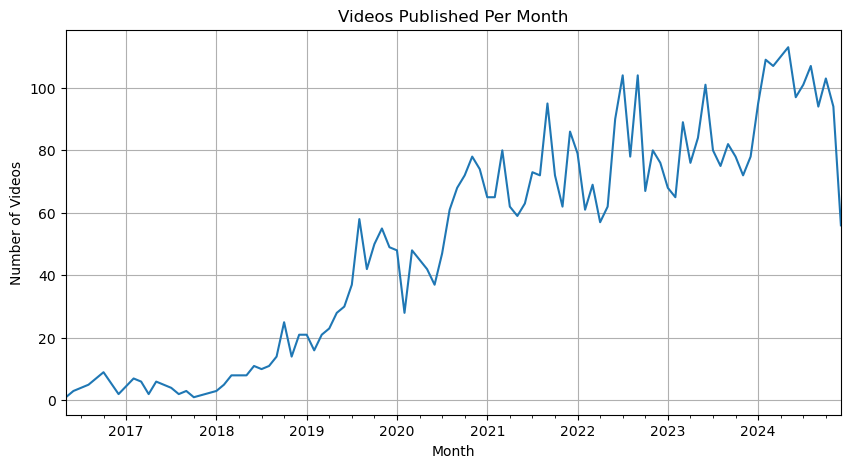

In [38]:
videos_per_month.plot(kind='line', title='Videos Published Per Month', figsize=(10,5))

plt.xlabel("Month")
plt.ylabel("Number of Videos")
plt.grid(True)

plt.show()

• Insight: The channel exhibits a strong growth trend in publishing frequency, transitioning from low and inconsistent uploads in early years to a sustained high-volume strategy in recent periods (peaking at over 100 videos per month), suggesting a deliberate scaling approach to increase content visibility, audience reach, and potential for viral performance.

In [39]:
# 11.What are the keywords we used the most in tags?

import ast
from collections import Counter

# function to convert string → list
def safe_eval(x):
    if pd.isna(x) or x == '':
        return []
    try:
        return ast.literal_eval(x)
    except:
        return []

# Apply conversion
df['tags_clean'] = df['tags'].apply(safe_eval)

# Flatten all tags
all_tags = [
    tag.lower().strip()
    for sublist in df['tags_clean']
    for tag in sublist
]

# Count frequency
tag_counts = Counter(all_tags).most_common(15)

print("Top 15 Most Used Tags:\n")
print(tag_counts)

Top 15 Most Used Tags:

[('netflix', 3775), ('netflix india', 3501), ('netflix shows', 2743), ('trailer', 268), ('comedy', 251), ('netflix movies', 248), ('bollywood', 232), ('new on netflix', 214), ('ranbir kapoor', 202), ('kapil sharma', 187), ('netflix series', 187), ('alia bhatt', 176), ('thriller', 175), ('official trailer', 160), ('srk', 160)]


In [40]:
tag_df = pd.DataFrame(tag_counts, columns=['Tag', 'Count'])
print(tag_df)

                 Tag  Count
0            netflix   3775
1      netflix india   3501
2      netflix shows   2743
3            trailer    268
4             comedy    251
5     netflix movies    248
6          bollywood    232
7     new on netflix    214
8      ranbir kapoor    202
9       kapil sharma    187
10    netflix series    187
11        alia bhatt    176
12          thriller    175
13  official trailer    160
14               srk    160


• Insight: Tag usage is dominated by a combination of strong brand identifiers (Netflix), content-type descriptors (trailers and shows), and Bollywood/celebrity-related keywords, suggesting that the channel strategically leverages brand recognition, familiar formats, and popular personalities to maximize discoverability and audience engagement.

In [41]:
# 12.What is the most used keyword in YT titles?

from collections import Counter
import re

# Combine all titles
all_titles = " ".join(df['title'].dropna()).lower()

# Remove special characters
clean_text = re.sub(r'[^a-zA-Z0-9\s]', '', all_titles)

# Remove stopwords
stopwords = ['the','and','of','to','a','in','for','on','with','at','by','an']

words = [word for word in clean_text.split() if word not in stopwords]

# Count keywords
word_counts = Counter(words)

# Get most common keyword
most_common_word = word_counts.most_common(1)

print("Most Used Keyword in Titles:\n")
print(most_common_word)

Most Used Keyword in Titles:

[('netflix', 3907)]


In [42]:
top_words = word_counts.most_common(10)

import pandas as pd
title_df = pd.DataFrame(top_words, columns=['Keyword', 'Count'])

print(title_df)

    Keyword  Count
0   netflix   3907
1     india   3299
2   trailer    768
3  official    751
4        ft    587
5         2    362
6    season    317
7    kapoor    295
8      more    260
9      khan    211


• Insight: Title keyword usage is heavily dominated by the brand name "netflix", alongside content-type descriptors (such as "trailer" and "official") and Bollywood-related terms (e.g., "kapoor", "khan"), suggesting that the channel strategically leverages brand identity, familiar formats, and culturally relevant keywords to enhance discoverability and audience engagement.

Insight:
* Long videos generate higher views and comments, indicating that long-form content performs better in engagement and reach.
- Engagement is strongly influenced by publishing time, with peak performance around 5–6 PM, while day has minimal impact.
+  Views follow a long-tail distribution, where a few videos generate most of the views while the majority perform moderately.
+ High-performing videos are driven by recognizable themes, especially Bollywood content and popular characters.
* Tags have limited impact on performance, as even videos without tags can achieve high views.


Recommendation:
- Focus on long-form, Bollywood, and character-driven content.
+ Publish videos during evening hours (5–10 PM).
* Maintain consistent high-volume uploads (2–3 videos/day).
- Prioritize content quality over excessive use of tags.
